# US Equity Portfolio - Data Exploration

## Project Context

This project analyzes a U.S. equity portfolio consisting of five individual holdings:

- **NVDA** - NVIDIA Corporation
- **JPM** - JPMorgan Chase & Co.
- **AMZN** - Amazon.com, Inc.
- **LLY** - Eli Lilly and Company
- **XOM** - Exxon Mobil Corporation

Portfolio performance is measured against the **S&P 500** (`^GSPC`) as the benchmark.

This notebook focuses specifically on **data inspection and exploratory analysis**: loading the
cached historical price dataset, validating its quality, and examining basic performance and
correlation patterns before any portfolio-level or risk modeling is applied. It reuses the
project's approved data-loading and metrics functions rather than reimplementing any
calculations.

## Imports and Configuration

Only the packages needed for this notebook are imported below. Project constants (tickers,
benchmark, portfolio weights) and the price-loading and metrics functions are imported directly
from the project's `config` module and approved `src` package rather than being redefined here.

The cell below locates the project root by walking upward from the current working directory
until it finds `config.py`, and adds it to `sys.path`. This makes the notebook work whether
Jupyter's working directory is the repository root or the `notebooks/` folder itself, without
hardcoding a relative path.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Locate the project root (the directory containing config.py) by walking upward."""
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "config.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root (config.py not found).")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\andhr\Downloads\us-equity-portfolio-analytics\us-equity-portfolio-analytics


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from config import BENCHMARK, TICKERS
from src import data_loader, metrics

sns.set_theme(style="whitegrid")
%matplotlib inline

## Load Cached Price Data

The cached, validated adjusted-close price dataset is loaded using the project's approved
`load_price_data()` function from `src.data_loader`. This function reads from
`data/processed/adjusted_close.csv` and performs full validation (no missing values, no
duplicate dates, positive prices, sufficient history) - it does not download or modify any
data. If the cache is missing, run the project's data pipeline once (e.g. `python main.py`)
before using this notebook.

In [3]:
prices = data_loader.load_price_data()

print(f"Shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Columns: {list(prices.columns)}")

Shape: (1254, 6)
Date range: 2021-09-13 to 2026-09-10
Columns: ['NVDA', 'JPM', 'AMZN', 'LLY', 'XOM', '^GSPC']


In [4]:
prices.head()

,NVDA,JPM,AMZN,LLY,XOM,^GSPC
Date,,,,,,
2021-09-13,22.054855,141.061493,172.858505,227.400940,46.468006,4468.729980
2021-09-14,22.144457,138.599609,172.500000,222.747009,45.805027,4443.049805
2021-09-15,22.243031,139.561432,173.789505,223.358612,47.349201,4480.700195
2021-09-16,22.144457,139.499664,174.412003,220.787979,46.845661,4473.750000
2021-09-17,21.803963,139.137833,173.126007,219.889679,46.291771,4432.990234


In [5]:
prices.tail()

,NVDA,JPM,AMZN,LLY,XOM,^GSPC
Date,,,,,,
2026-09-03,228.194656,362.059998,258.899994,1159.599976,162.210007,7747.709961
2026-09-04,230.102524,358.640015,258.510010,1149.359985,159.470001,7718.600098
2026-09-08,225.477692,353.510010,256.970001,1123.910034,160.660004,7673.520020
2026-09-09,223.419998,354.709991,252.399994,1124.209961,164.229996,7636.359863
2026-09-10,218.360001,353.559998,251.889999,1123.000000,165.229996,7591.700195


## Data Quality Checks

Beyond the validation already performed inside `load_price_data()`, the checks below give a
transparent, visible confirmation of the dataset's integrity directly in the notebook.

In [6]:
missing_by_column = prices.isna().sum()
duplicate_dates = int(prices.index.duplicated().sum())
non_positive_count = int((prices <= 0).sum().sum())

print("Missing values by column:")
print(missing_by_column)
print(f"\nDuplicate date count: {duplicate_dates}")
print(f"Non-positive price count: {non_positive_count}")

quality_checks_passed = (
    missing_by_column.sum() == 0
    and duplicate_dates == 0
    and non_positive_count == 0
)
status = "PASSED" if quality_checks_passed else "FAILED"
print(f"\nData quality checks: {status}")

Missing values by column:
NVDA     0
JPM      0
AMZN     0
LLY      0
XOM      0
^GSPC    0
dtype: int64

Duplicate date count: 0
Non-positive price count: 0

Data quality checks: PASSED


## Normalized Price Performance

To compare assets of very different price levels on a single chart, every series (the five
holdings and the S&P 500 benchmark) is rescaled so that its first observation in the sample
equals 100.

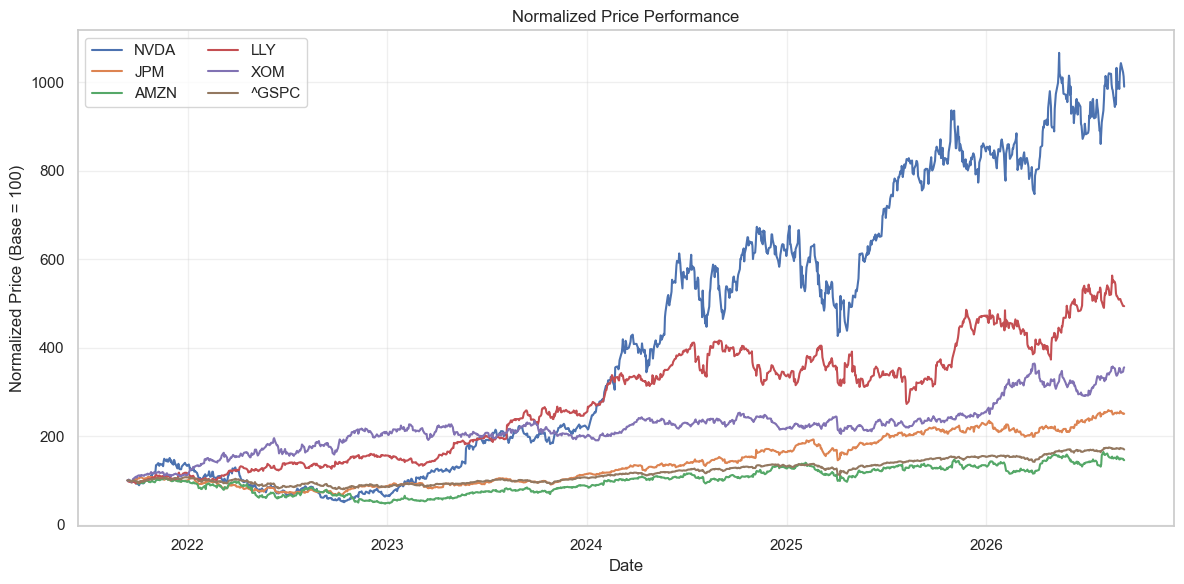

In [7]:
normalized_prices = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))
for column in normalized_prices.columns:
    ax.plot(normalized_prices.index, normalized_prices[column], label=column, linewidth=1.5)

ax.set_title("Normalized Price Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100)")
ax.legend(loc="upper left", ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Each series above is rescaled to start at 100 on the first date in the sample, so the lines
show relative, cumulative growth rather than absolute dollar prices - this makes it possible to
compare assets with very different price levels on the same chart. A line finishing higher than
another indicates that asset produced a larger cumulative percentage gain over the period shown,
though this view alone says nothing about volatility, drawdowns, or risk-adjusted return. It is
a starting point for exploration, not a complete performance comparison.

## Daily Returns

Daily percentage returns are calculated using the project's approved `calculate_daily_returns()`
function from `src.metrics`. The table below summarizes the distribution of daily returns for
each asset and the benchmark.

In [8]:
returns = metrics.calculate_daily_returns(prices)

return_stats = returns.agg(["mean", "std", "min", "max"]).T
return_stats.columns = ["Mean", "Std Dev", "Min", "Max"]
return_stats

,Mean,Std Dev,Min,Max
NVDA,0.002363,0.032791,-0.169682,0.243696
JPM,0.000852,0.015384,-0.074838,0.115445
AMZN,0.000563,0.022980,-0.140494,0.153206
LLY,0.001487,0.020645,-0.141364,0.148696
XOM,0.001154,0.016793,-0.078853,0.064113
^GSPC,0.000481,0.010741,-0.059750,0.095154


## Return Distribution

The chart below overlays the daily return distribution for each portfolio holding, using a
smoothed density estimate rather than separate histograms per asset to keep the view compact
and readable.

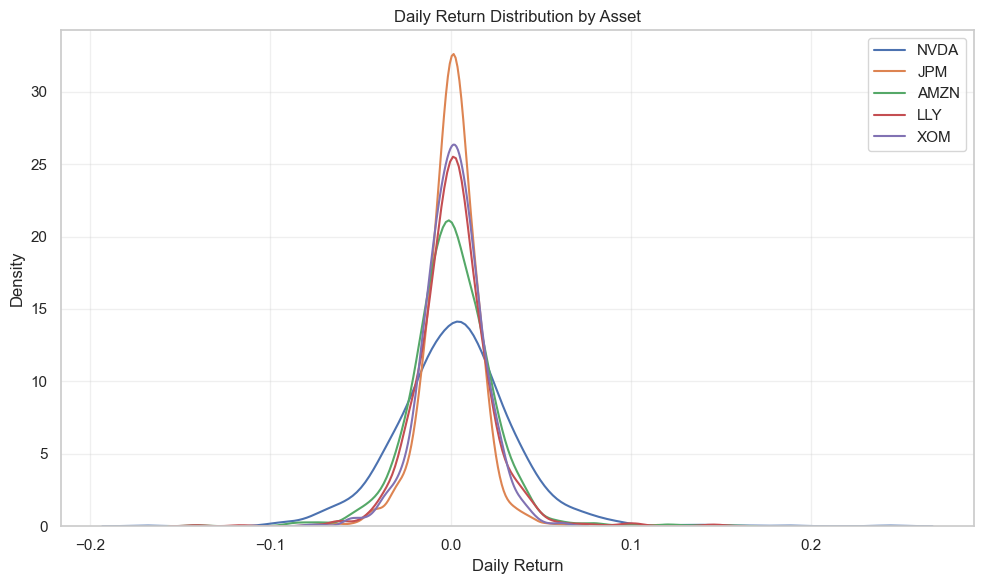

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
for ticker in TICKERS:
    sns.kdeplot(returns[ticker], label=ticker, ax=ax, linewidth=1.5)

ax.set_title("Daily Return Distribution by Asset")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Correlation

Pairwise correlation of daily returns (for all holdings and the benchmark) is calculated using
the project's approved `calculate_correlation_matrix()` function from `src.metrics`.

In [10]:
correlation_matrix = metrics.calculate_correlation_matrix(returns)
correlation_matrix.round(3)

,NVDA,JPM,AMZN,LLY,XOM,^GSPC
NVDA,1.000,0.325,0.523,0.157,0.056,0.712
JPM,0.325,1.000,0.354,0.167,0.272,0.618
AMZN,0.523,0.354,1.000,0.156,0.074,0.705
LLY,0.157,0.167,0.156,1.000,0.052,0.300
XOM,0.056,0.272,0.074,0.052,1.000,0.253
^GSPC,0.712,0.618,0.705,0.300,0.253,1.000


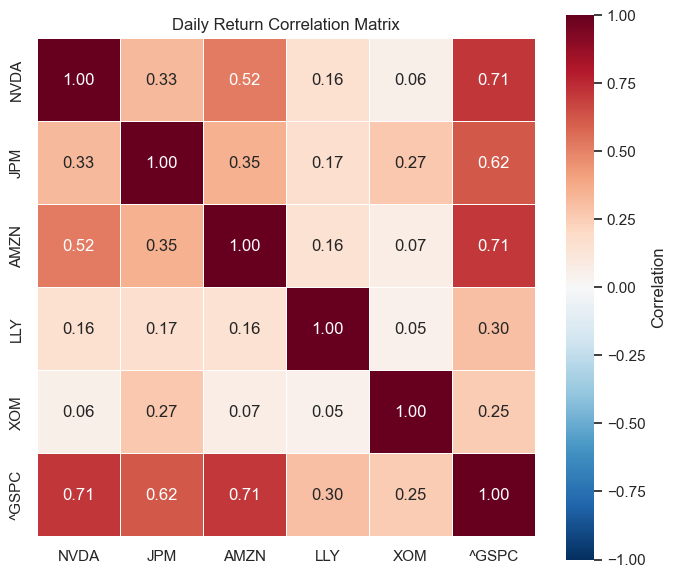

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Daily Return Correlation Matrix")
fig.tight_layout()
plt.show()

Assets whose returns move more closely together - both with each other and with the S&P 500
benchmark - offer less diversification benefit within the portfolio, since they tend to gain and
lose value at the same time. Assets with comparatively lower correlation to the rest of the
group can help smooth overall portfolio volatility. The specific patterns observed in this
dataset are summarized in the findings below.

## Key Exploratory Findings

Based on the data inspected above:

- The dataset spans roughly five years of daily trading history for all five portfolio holdings
  and the S&P 500 benchmark, providing a reasonably long window for exploratory analysis.
- NVDA and AMZN tend to show relatively higher correlation with the S&P 500 benchmark than the
  other holdings, consistent with their weight and behavior as large, broadly-held growth names.
- LLY and XOM tend to show comparatively lower correlation with the benchmark and with the rest
  of the portfolio, suggesting they may contribute more diversification within this specific
  asset mix.
- These are descriptive, historical observations only. They do not imply that these
  relationships will persist, and nothing in this notebook should be interpreted as investment
  advice or a prediction of future performance. Portfolio-level risk/return, signal, and
  simulation analysis are covered in the project's other notebooks and in `main.py`.